In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Monte-Carlo Sampling

## Sum vs Mixture

If one sums two random variables $X$ and $Y$ then a PDF of new rand. var. $Z=X+Y$ is a convolution of PDF_x and PDF_y.

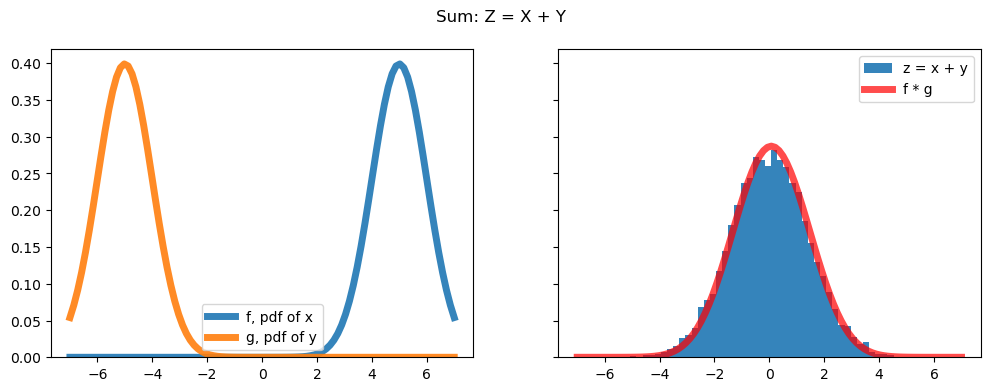

In [2]:
f = norm(5)
g = norm(-5)
x = np.linspace(-7, 7, 100)

summation = f.rvs(size=10_000) + g.rvs(size=10_000)
convolution = np.convolve(f.pdf(x), g.pdf(x), "same") / sum(g.pdf(x))  # f_x * g_y (z) = \int f(t) g(z - t) dt   

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(x, f.pdf(x), lw=5, alpha=.9, label='f, pdf of x')
axs[0].plot(x, g.pdf(x), lw=5, alpha=.9, label='g, pdf of y')

axs[1].hist(summation, bins=50, density=True, alpha=.9, label='z = x + y')
axs[1].plot(x, convolution, 'r', lw=5, alpha=.7, label='f * g')

fig.suptitle("Sum: Z = X + Y")
_ = [ax.legend() for ax in axs]

When we want to sum PDFs themself, the new RV is called a mixture. To sample from a mixture of weighted gaussians below we employ built-in method of scipy.stats -- one need only extend abstract class `rv_continuous` and provide a new density in its private function `_pdf`

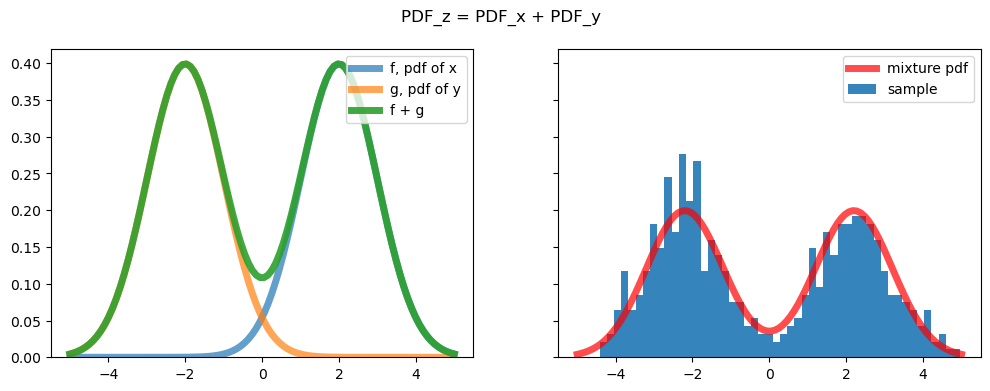

In [3]:
from scipy.stats import rv_continuous
from scipy import special


class mixture_gen(rv_continuous):
    
    def _pdf(self, x, d, weight):
        f = np.exp(-(x - d)**2 / 2.) / np.sqrt(2.0 * np.pi)
        g = np.exp(-(x + d)**2 / 2.) / np.sqrt(2.0 * np.pi)
        return  weight * f + (1 - weight) * g
    

## implementing _ppf will produce a great speed up 
## (this exact one is not for our mixture)

# quantile | percent-point | inverse cumulative distribution function.
#     def _ppf(self, q, d, w):
#         return mu + np.sqrt(2) * sigma * special.erfinv(2*q-1)
    
mixture = mixture_gen(name='mixture')

f = norm(2) #frozen istribution
g = norm(-2)
m = mixture(2.2, 0.5)

x = np.linspace(-5, 5, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axs[0].plot(x, f.pdf(x), lw=5, alpha=.7, label='f, pdf of x')
axs[0].plot(x, g.pdf(x), lw=5, alpha=.7, label='g, pdf of y')
axs[0].plot(x, f.pdf(x) + g.pdf(x), lw=5, alpha=.9, label='f + g')

mixture_sample = m.rvs(size=500)

axs[1].plot(x, m.pdf(x), 'r', lw=5, alpha=.7, label='mixture pdf')
axs[1].hist(mixture_sample, bins=50, density=True, alpha=.9, label='sample')

fig.suptitle("PDF_z = PDF_x + PDF_y")
_ = [ax.legend() for ax in axs]

## 1. Direct-Sampling by Rejection


sampling efficiency = 0.2801
pi = 3.112222222222222


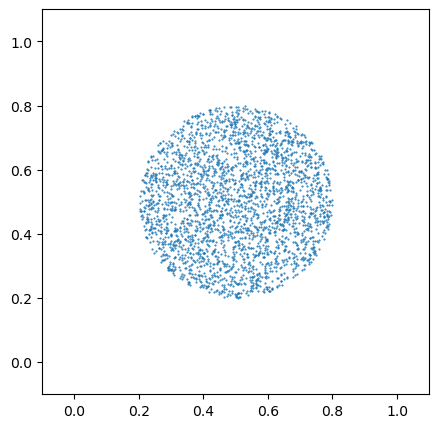

In [4]:
N = 10_000  # number of dots
R = 0.3

count = 0
x_in = []
y_in = []

x = np.random.uniform(size=N) # generate samples uniformly distributed within a square
y = np.random.uniform(size=N)

for i in range(0, N):
    if (x[i] - 0.5)**2 + (y[i] - 0.5)**2 < R**2:  # accept if the sample within the sphere
        count = count + 1
        x_in.append(x[i])
        y_in.append(y[i])

fig, ax = plt.subplots(1, 1, figsize=(5, 5))       
ax.plot(x_in, y_in, '.-', lw=0, ms=1)
ax.set(xlim=(-0.1, 1.1), ylim=(-0.1, 1.1))

print(f"sampling efficiency = {count / N}")
print(f"pi = {count / (N * R**2)}")         # estimation for \pi

## 2. MCMC (Monte-Carlo Markov Chain)

sampling efficiency = 0.806
pi = 3.224


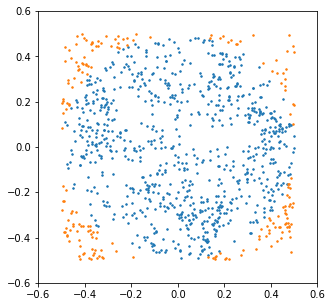

In [97]:
N = 1000  # number of steps
R = 0.5

dx = 0.05 # step size

count = 0
xy_in = [[], []]
xy_out = [[], []]
walk = [[], []]

x=1.0 # Initial coordinates
y=1.0
for i in range(1, N):
    x = x + dx * np.random.normal(0, 1)
    y = y + dx * np.random.normal(0, 1)

    # periodic boundary conditions for the walker
    if x > 0.5:
        x = x - 1
    if x < -0.5:
        x = x + 1
    if y > 0.5:
        y = y - 1
    if y < -0.5:
        y = y + 1

    if x**2 + y**2 < R**2:
        count = count + 1
        xy_in[0].append(x)
        xy_in[1].append(y)
    else:
        xy_out[0].append(x)
        xy_out[1].append(y)
    walk[0].append(x)
    walk[1].append(y)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))       
ax.plot(xy_in[0], xy_in[1], '.', ms=3)
ax.plot(xy_out[0], xy_out[1], '.', ms=3)
# ax.plot(walk[0], walk[1], 'black', lw=1)
ax.set(xlim=(-0.6, 0.6), ylim=(-0.6, 0.6))

print(f"sampling efficiency = {count / N}")
print(f"pi = {count / (N * R**2)}")

## 3. Direct Sampling by Rejection (exponential)

Let us now show how to get positive Gaussian (normal) random variable from an exponential random variable through rejection. 

* First, one samples from the exponential distribution: $x \sim \rho_0(x)=\begin{cases} e^{-x} & x>0, \\ 0  &\text{otherwise}\end{cases}$

* Second, aiming to get a sample from the positive half of Gaussian, $x\sim  \rho(x)=\begin{cases}\sqrt{2/\pi}\exp(-x^2/2) & x>0,\\ 0 &\text{otherwise}\end{cases}$,\
  one accepts the generated sample with the probability 
  
  $$ p(x)=\frac{1}{M}\sqrt{2/\pi}\exp(x-x^2/2)$$ 
  
  where $M$ is a constant which should be larger than, $\max(\rho (x) / \rho_0(x)) = \sqrt{2/\pi} \, e^{1/2} \approx 1.32$, to guarantee that $p(x)\leq 1$ for all $x>0$.

sampling efficiency = 0.09916306374201737
1/M = 0.1


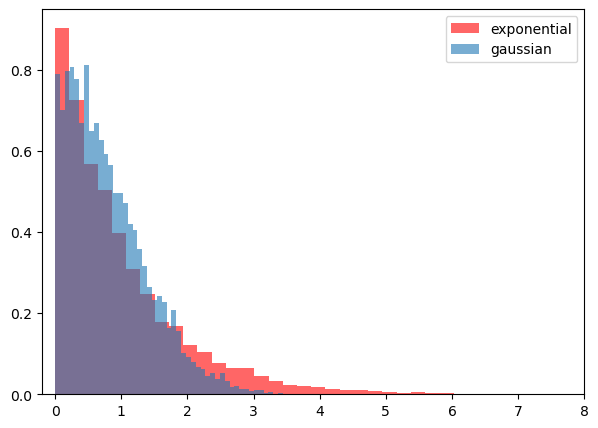

In [17]:
def rho_0_pdf(x):    # initial: exponential distribution
    return np.exp(-x)

def rho_pdf(x):      # desired: Gaussian distribution
    return (2 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

N = 10_000
M = 10 # change here 
rand_var = []
rejected = 0
i = 1

while i < N: # sampling procedure 
    
    sample = np.random.exponential()
    p = rho_pdf(sample) / rho_0_pdf(sample) / M
    
    if np.random.uniform() < p:
        rand_var.append(sample)
        i += 1
    else:
        rejected += 1
        
rho0 = np.random.exponential(size=N) # initial distribution sample

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(rho0, bins=50, color="red", density=True, alpha=.6, label='exponential')
ax.hist(rand_var, bins=50, density=True, alpha=.6, label='gaussian')
ax.set_xlim(-0.2, 8)
ax.legend()

print(f"sampling efficiency = {N / (rejected + N)}")
print(f"1/M = {1 / M}")

Note that the rejection algorithm has the advantage that it can be applied even when the probability densities are known only upto a multiplicative constant.

## 4. Importance Sampling

Suppose we want to compute an expectation of a function, $f(x)$, over the distribution, $\rho(x)$, i.e. $\int dx \rho(x) f(x)$, in the regime where $f(x)$ and $\rho(x)$ are concentrated around very different $x$. In this case overlap of $f$ and $\rho(x)$ is small and as a result a lot of MC samples will be 'wasted'. 

Importance Sampling is the method which helps to fix the small-overlap problem. It is based on adjusting the distribution function from $\rho(x)$ to $\rho_0(x)$ and then utilizing the following formula:

$$ \mathbb{E}_{\rho}[f(x)]=\int dx \rho(x) f(x)=\int dx \rho_0(x) \frac{f(x)\rho(x)}{\rho_0(x)}=\mathbb{E}_{\rho_0}\left[\frac{f(x)\rho(x)}{\rho_0(x)}\right]$$

Consider an illustrative DS example, $\rho(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right)$ and $f(x)=\exp\left(-\frac{(x-4)^2}{2}\right)$, vs IS with the proposal distribution, $\rho_0(x)=\frac{1}{\sqrt{\pi}}\exp\left(-(x-2)^2\right)$.

Direct Sampling <f>: 0.015127045029762311, Importance Sampling <f>:0.012951112459987979


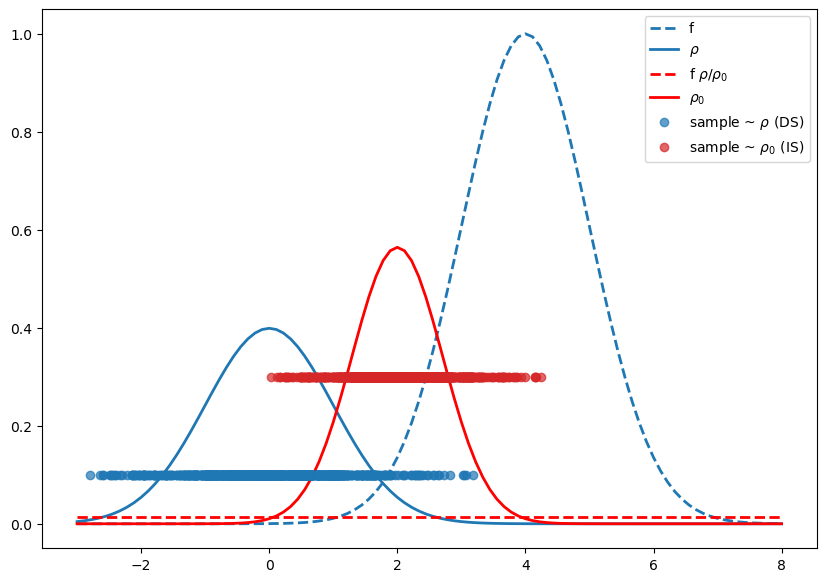

In [20]:
N = 1000

# Samples
x = np.random.normal(size=N)  # sample from rho
xp = x / np.sqrt(2) + 2       # sample from rho_0

# <f> ~ DS:
DS_f  = np.sum(np.exp(-0.5 * (x - 4)**2))

# <f * rho / rho_0 >_0 ~ IS:
IS_f = np.sum(np.exp(-0.5 * (xp - 4)**2 - 0.5 * xp**2 + (xp - 2)**2) / np.sqrt(2))

# Functions
x0 = np.linspace(-3, 8, 100)

f  = np.exp(-0.5 * (x0 - 4)**2)
fp0 = np.exp(-0.5 * (x0 - 4)**2 - 0.5 * x0**2 + (x0 - 2)**2) / np.sqrt(2)

rho = np.exp(- x0**2 / 2) / np.sqrt(2 * np.pi)
rho0 = np.exp(-(x0 - 2)**2) / np.sqrt(np.pi)

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.plot(x0, f,  color="tab:blue", linewidth=2.0, linestyle="--", label="f")
ax.plot(x0, rho, color="tab:blue", linewidth=2.0, linestyle="-",  label="$\\rho$")
ax.plot(x0, fp0, color="red", linewidth=2.0, linestyle="--", label="f $\\rho / \\rho_0$")
ax.plot(x0, rho0, color="red", linewidth=2.0, linestyle="-", label="$\\rho_0$")
ax.plot(x, 0.1 * np.ones(N), "o", alpha=0.7, color="tab:blue", label="sample ~ $\\rho$ (DS)")
ax.plot(xp, 0.3 * np.ones(N), "o", alpha=0.7, color="tab:red", label="sample ~ $\\rho_0$ (IS)")
ax.legend()

print(f"Direct Sampling <f>: {DS_f/N}, Importance Sampling <f>:{IS_f/N}")

We are clearly wasting samples with Direct Sampling.

Note one big problem with Importance Sampling. In the real (multi-dimensional) cases we typically do not have a good guess for $\rho_0(x)$.

In [14]:
import numpy as np

# ----------------------------
# Parameters
# ----------------------------
np.random.seed(42)
n = 20_000_000      # Sample size (large for stability)
a = 0.8          # Threshold: negative dep. on [0, a], pos. on (a, 1]
k = 5             # Exponential scaling (increase if no flip)

U = np.random.uniform(0, 1, n)
X = U
Y = np.where(U <= a, 1 - U, U)  # Negative dep. for U<=a, else Y=X

cov_original = np.cov(X, Y, bias=True)[0, 1]
print(f"Original Cov(X, Y) = {cov_original:.6f}")

fX = np.exp(k * X)
fY = np.exp(k * Y)
cov_transformed = np.cov(fX, fY, bias=True)[0, 1]
print(f"Transformed Cov(f(X), f(Y)) = {cov_transformed:.6f}  (k = {k})")

Original Cov(X, Y) = -0.018005
Transformed Cov(f(X), f(Y)) = 610.844181  (k = 5)
